<a href="https://colab.research.google.com/github/AdhamAshraf2323/Loan-Predication/blob/master/Bank_Loan_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Loan Eligibility Prediction
**problem**: Manual Evaluation&Time-Consuming Workflow
**Objective:** Automate real-time loan approval decisions using a classification model.

---


## 1. Environment Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Data Understanding


### feature grouping
| Group                 | Features                                                         |
| --------------------- | ---------------------------------------------------------------- |
| **Applicant Profile** | Gender, Married, Dependents, Education, Self_Employed            |
| **Financial Profile** | ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term |
| **Credit Profile**    | Credit_History                                                   |
| **Identifier**        | Loan_ID                                                          |
| **Target Variable**   | Loan_Status                                                      |


In [2]:
df.shape

(614, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [5]:
missing_values_summary = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(2)
})
missing_values_summary = (missing_values_summary[missing_values_summary["Missing"] > 0]
                          .sort_values(by="Missing", ascending=False))
missing_values_summary

,Missing,Percentage (%)
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

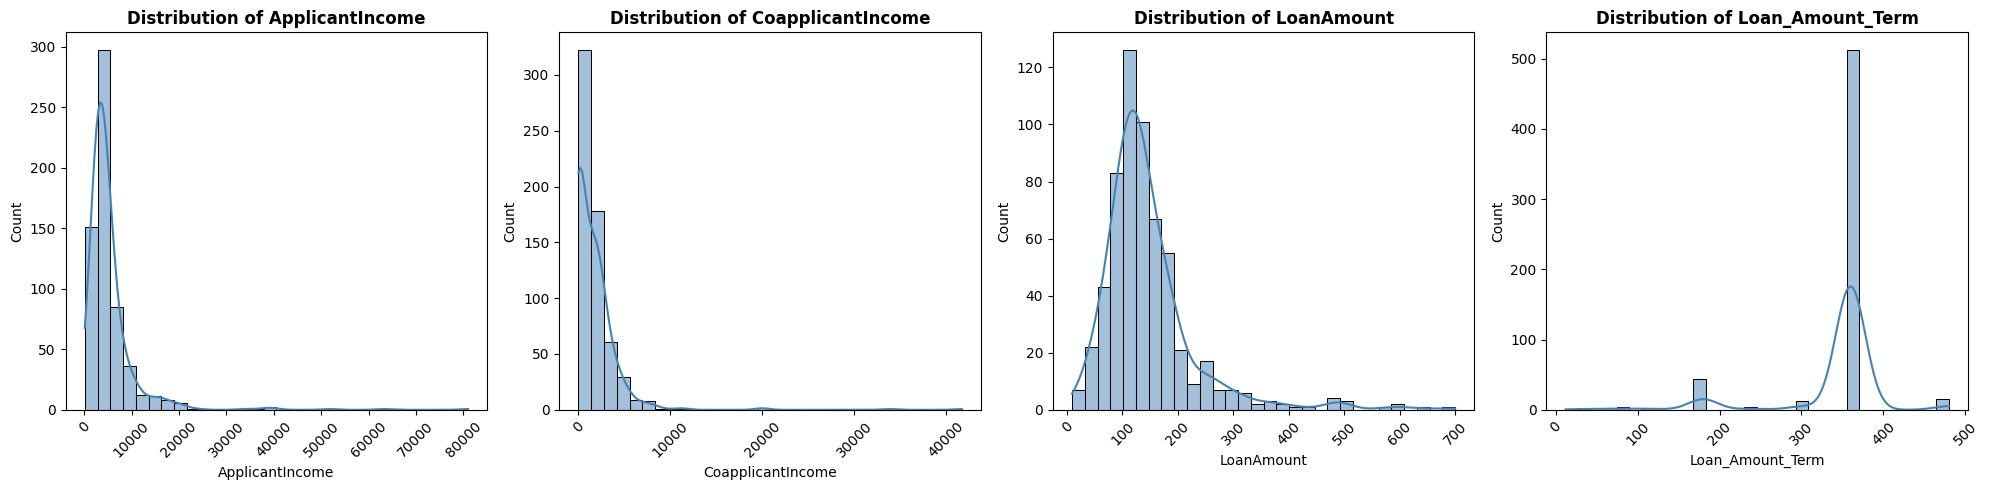

In [8]:

cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# زيادة العرض قليلاً ليتسع لـ 4 رسومات براحة
fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')

    # تدوير الأرقام التلقائية فقط لتجنب تداخلها
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

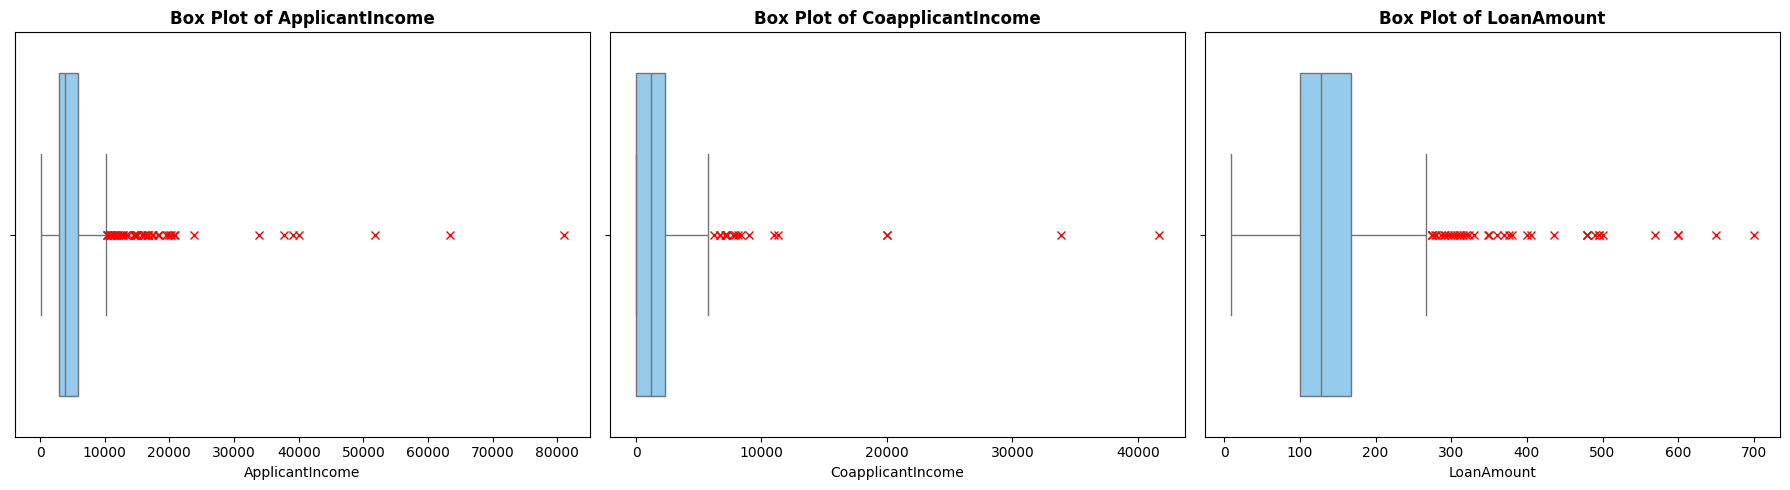

In [9]:

outlier_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))

for i, col in enumerate(outlier_cols):
    # رسم الصندوق أفقياً (orient='h') ليكون مريحاً في المقارنة مع الهستوغرام
    sns.boxplot(x=df[col], ax=axes[i], color='lightskyblue', flierprops={"marker": "x", "markeredgecolor": "red"})
    axes[i].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_834/642348673.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='Set2')


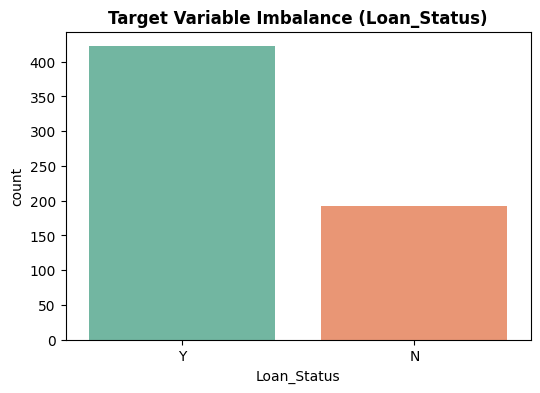

In [10]:

target_pct = df['Loan_Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title('Target Variable Imbalance (Loan_Status)', fontweight='bold')
plt.show()

## 🎯 sprint 1 dleviralbe:
### Findings

- `Loan_ID` is a unique identifier and is not expected to contribute to prediction.
- Missing values exist in `Gender`, `Married`, `Dependents`, and `Self_Employed`.
- `Education` and `Property_Area` contain no missing values.
- **Most applicants are male, married, graduates, and not self-employed.**
- The target variable `(Loan_Status)` is slightly imbalanced toward approved loans.

GO / NO-GO Decision
> 🟢 **Decision: GO**
> **Justification:** The dataset contains sufficient records and logical features to build a baseline predictive model. The identified issues (missing values, skewness, and slight imbalance) are standard data quality problems that can be effectively resolved in the upcoming Data Preparation phase.

## Data Preparation(cleaning&preprocessing)

####handle nulls

In [11]:
df_clean = df.copy()

In [12]:
df_clean['Credit_History'] = (df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0]))

In [13]:
df_clean['Credit_History'].isna().sum()

np.int64(0)

In [14]:
df_clean['Self_Employed'] = (df_clean['Self_Employed'].fillna((df_clean['Self_Employed'].mode()[0])))

In [15]:
df_clean['Self_Employed'].isna().sum()

np.int64(0)

In [16]:
df_clean['LoanAmount'] = (df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median()))

In [17]:
df_clean['LoanAmount'].isna().sum()

np.int64(0)

In [18]:
df_clean['Dependents'] = (df_clean['Dependents'].fillna((df_clean['Dependents'].mode()[0])))

In [19]:
df_clean['Dependents'].isna().sum()

np.int64(0)

In [20]:
df_clean['Gender'] = (df_clean['Gender'].fillna((df_clean['Gender'].mode()[0])))
df_clean['Married'] = (df_clean['Married'].fillna((df_clean['Married'].mode()[0])))
print(df_clean['Married'].isna().sum(),df_clean['Gender'].isna().sum())

0 0


In [21]:
df_clean['Loan_Amount_Term'] = (df_clean['Loan_Amount_Term'].fillna((df_clean['Loan_Amount_Term'].mode()[0])))
df_clean['Loan_Amount_Term'].isna().sum()

np.int64(0)

In [22]:
df_clean.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


####handle outlires

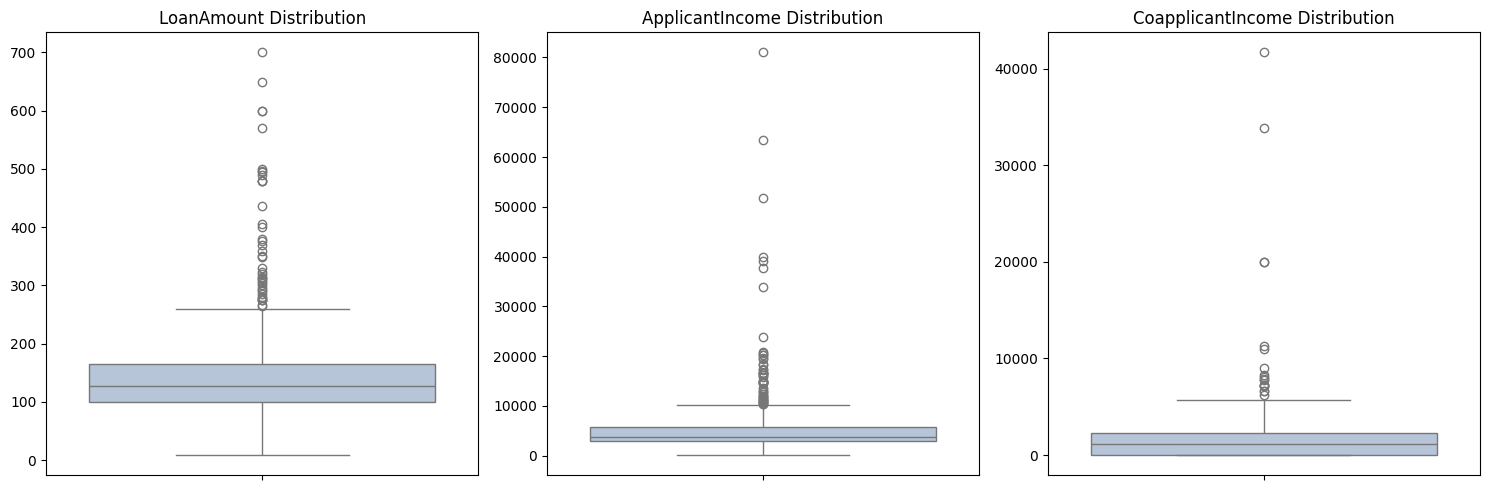

In [23]:

# اختيار الأعمدة الرقمية فقط وتصحيح اسم القائمة
numeric_columns = ['LoanAmount', 'ApplicantIncome','CoapplicantIncome' ]

# إنشاء شبكة رسوم بيانية (صف واحد و 3 أعمدة) لعرضها جنباً إلى جنب
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(15, 5))

# رسم المخططات الصندوقية داخل الشبكة
for i, col in enumerate(numeric_columns):
    sns.boxplot(data=df_clean, y=col, ax=axes[i], color='lightsteelblue')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_ylabel('') # إزالة التسمية الجانبية لتنظيف الشكل الجمالي

# ترتيب المسافات بين المخططات تلقائياً
plt.tight_layout()
plt.show()

In [24]:
df_clean['LoanAmount'].describe()

,LoanAmount
count,614.000000
mean,145.752443
std,84.107233
min,9.000000
25%,100.250000
50%,128.000000
75%,164.750000
max,700.000000


In [25]:

Q1_loan = df_clean['LoanAmount'].quantile(0.25)
Q3_loan = df_clean['LoanAmount'].quantile(0.75)

# حساب المدى الربيعي
IQR_loan = Q3_loan - Q1_loan

print(f"IQR for LoanAmount: {IQR_loan}")

# (اختياري) تحديد الحدود الدنيا والعليا لاكتشاف القيم الشاذة
              #100K           64K
lower_bound = Q1_loan - 1.5 * IQR_loan
upper_bound = Q3_loan + 1.5 * IQR_loan
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

IQR for LoanAmount: 64.5
Lower Bound: 3.5, Upper Bound: 261.5


In [26]:
df_LoanAmount_filtered = df_clean[(df_clean['LoanAmount'] >= lower_bound) &
                                  (df_clean['LoanAmount'] <= upper_bound)].copy()
print(f"عدد الأسطر قبل التصفية: {len(df_clean['LoanAmount'])}")
print(f"عدد الأسطر بعد التصفية: {len(df_LoanAmount_filtered)}")


عدد الأسطر قبل التصفية: 614
عدد الأسطر بعد التصفية: 573


In [27]:
df_LoanAmount_filtered['LoanAmount_Log'] = np.log1p(df_LoanAmount_filtered['LoanAmount'])


print(df_LoanAmount_filtered[['LoanAmount', 'LoanAmount_Log']].head())

   LoanAmount  LoanAmount_Log
0       128.0        4.859812
1       128.0        4.859812
2        66.0        4.204693
3       120.0        4.795791
4       141.0        4.955827


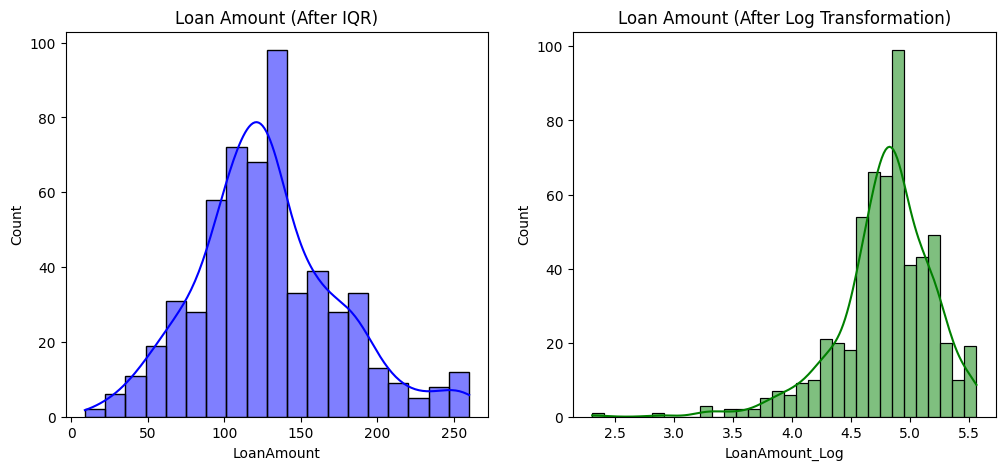

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# الرسم الأول: البيانات الأصلية (مائلة ومحذوف منها الشاذ بالـ IQR)
sns.histplot(df_LoanAmount_filtered['LoanAmount'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Loan Amount (After IQR)')

# الرسم الثاني: البيانات بعد اللوغاريتم (ستلاحظ أنها أصبحت متماثلة كالجرس)
sns.histplot(df_LoanAmount_filtered['LoanAmount_Log'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Loan Amount (After Log Transformation)')

plt.show()


####Since we will be using a model that assumes a normal distribution, we will omit the logarithmic transformation.

In [29]:
df_LoanAmount_filtered.drop('LoanAmount_Log', axis=1, inplace=True)
df_LoanAmount_filtered.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 🎯 sprint 2 dleviralbe:

### Encoding

In [33]:

# df_LoanAmount_filtered['Gender'] = df_LoanAmount_filtered['Gender'].map({'Female': 0, 'Male': 1})
# df_LoanAmount_filtered['Gender'].value_counts()

In [34]:
# df_LoanAmount_filtered['Married'] = df_LoanAmount_filtered['Married'].map({'No': 0, 'Yes': 1})
# df_LoanAmount_filtered['Married'].unique()

In [35]:
# df_LoanAmount_filtered['Education'] = df_LoanAmount_filtered['Education'].map({'Not Graduate': 0, 'Graduate': 1})

# df_LoanAmount_filtered['Education'].unique()


In [36]:
# print(df_LoanAmount_filtered[['Gender', 'Married', 'Education']].head())

In [37]:
# print(df_LoanAmount_filtered['Property_Area'].unique())


In [38]:
# print(df_LoanAmount_filtered['Self_Employed'].unique())

In [39]:
# df_LoanAmount_filtered['Property_Area'] = df_LoanAmount_filtered['Property_Area'].map({'Urban':1,'Semiurban':2,'Rural':3})
# df_LoanAmount_filtered['Property_Area'].unique()

In [40]:
# df_LoanAmount_filtered['Self_Employed'] = df_LoanAmount_filtered['Self_Employed'].map({'No':0,'Yes':1})
# df_LoanAmount_filtered['Self_Employed'].unique()

In [41]:
# df_LoanAmount_filtered['Loan_Status'] = df_LoanAmount_filtered['Loan_Status'].map({'N':0,'Y':1})
# df_LoanAmount_filtered['Loan_Status'].unique()

In [42]:
df_LoanAmount_filtered.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [43]:
# df_LoanAmount_filtered.info()

In [44]:
# df_LoanAmount_filtered['Dependents'].unique()

In [45]:
# df_LoanAmount_filtered['Dependents'] = df_LoanAmount_filtered['Dependents'].map({
#     '0': 0,
#     '1': 1,
#     '2': 2,
#     '3+': 3
# })

# print(df_LoanAmount_filtered['Dependents'].unique())
# print(df_LoanAmount_filtered['Dependents'].dtype)

In [46]:
# df_LoanAmount_filtered.to_excel('clean_data.xlsx', index=False)